# Module 06 — Trees and Ensembles

Gradient-boosted trees are, as of today, the default winner on tabular data.
That is an empirical fact worth knowing and a poor substitute for
understanding *why* — which is what lets you predict when it will not be true,
and what to do then.

This module builds up from a single split to the state of the art, and ends
with the honest comparison against XGBoost, LightGBM and CatBoost.

### Learning objectives

1. Compute an impurity-reducing split by hand and match `DecisionTreeClassifier`.
2. Explain the bias–variance argument for bagging and for boosting — they are
   opposite arguments.
3. Control tree complexity with the parameters that actually matter.
4. Use `HistGradientBoosting`'s modern features: native categoricals, early
   stopping, monotonic and interaction constraints.
5. Say when XGBoost/LightGBM/CatBoost earn their dependency and when they do
   not.
6. Distrust `feature_importances_` for the specific reason it deserves.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])
X_enc = X.copy()
for c in X_enc.select_dtypes(include=["object", "string"]).columns:
    X_enc[c] = X_enc[c].astype("category")

## 1. One split, by hand

A classification tree chooses the split that most reduces **impurity**. Gini
impurity of a node with class proportions `p` is `1 − Σp²`; entropy is
`−Σ p log p`. The gain from a split is the parent's impurity minus the
weighted average of the children's.

That is the whole algorithm, applied recursively.

In [2]:
def gini(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y, minlength=2) / len(y)
    return 1.0 - (p**2).sum()


def best_split(x, y):
    """Exhaustive scan over midpoints between sorted unique values."""
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    parent = gini(ys)
    n = len(ys)
    best = {"gain": -np.inf}
    # candidate thresholds: midpoints where x changes
    cut_points = np.where(np.diff(xs) > 0)[0]
    for i in cut_points:
        left, right = ys[: i + 1], ys[i + 1 :]
        weighted = (len(left) * gini(left) + len(right) * gini(right)) / n
        gain = parent - weighted
        if gain > best["gain"]:
            best = {"gain": gain, "threshold": (xs[i] + xs[i + 1]) / 2,
                    "n_left": len(left), "n_right": len(right)}
    return best


feature = "credit_score"
mask = credit[feature].notna()
xv = credit.loc[mask, feature].to_numpy(dtype=float)
yv = credit.loc[mask, "default"].to_numpy()

mine = best_split(xv, yv)
print(f"parent gini            : {gini(yv):.6f}")
print(f"best threshold (mine)  : {mine['threshold']:.4f}")
print(f"impurity decrease      : {mine['gain']:.6f}")

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(xv.reshape(-1, 1), yv)
print(f"\nbest threshold (sklearn): {stump.tree_.threshold[0]:.4f}")
print(f"sklearn impurity decrease: {stump.tree_.impurity[0] - (stump.tree_.weighted_n_node_samples[1] * stump.tree_.impurity[1] + stump.tree_.weighted_n_node_samples[2] * stump.tree_.impurity[2]) / stump.tree_.weighted_n_node_samples[0]:.6f}")

parent gini            : 0.227441
best threshold (mine)  : 586.5000
impurity decrease      : 0.020535



best threshold (sklearn): 586.5000
sklearn impurity decrease: 0.020535


Identical. `DecisionTreeClassifier` is doing exactly this, for every feature,
at every node, with a lot of Cython.

Three consequences of the mechanism worth internalising:

1. **Splits are thresholds, so trees are invariant to any monotone transform
   of a feature.** Log it, square-root it, standardise it — same tree. This is
   why scaling does nothing for trees.
2. **Trees are axis-aligned.** A diagonal decision boundary must be
   approximated by a staircase, which takes many splits.
3. **The search is greedy.** The best split now is not necessarily part of the
   best tree. Trees do not find optimal trees, and no practical algorithm does.

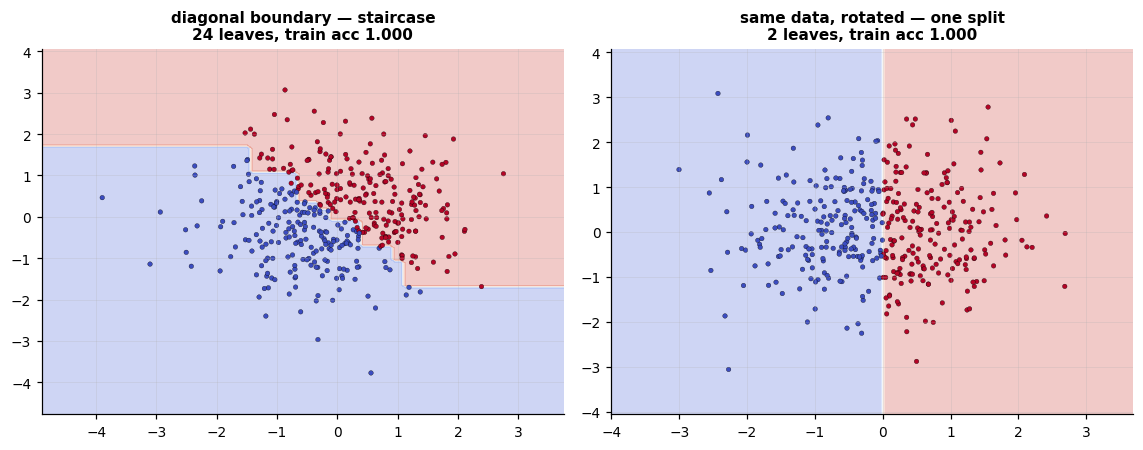

In [3]:
# Axis-alignment, visualised: the same problem rotated 45°.
from sklearn.inspection import DecisionBoundaryDisplay

Xd = rng.normal(size=(400, 2))
yd = (Xd[:, 0] + Xd[:, 1] > 0).astype(int)          # a diagonal boundary
R = np.array([[np.cos(np.pi / 4), -np.sin(np.pi / 4)], [np.sin(np.pi / 4), np.cos(np.pi / 4)]])
Xr = Xd @ R                                          # rotate so the boundary is axis-aligned

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, (Xi, title) in zip(axes, [(Xd, "diagonal boundary — staircase"), (Xr, "same data, rotated — one split")]):
    t = DecisionTreeClassifier(max_depth=6, random_state=0).fit(Xi, yd)
    DecisionBoundaryDisplay.from_estimator(t, Xi, ax=ax, alpha=0.28, cmap="coolwarm", response_method="predict")
    ax.scatter(Xi[:, 0], Xi[:, 1], c=yd, s=9, cmap="coolwarm", edgecolor="k", linewidth=0.2)
    ax.set_title(f"{title}\n{t.get_n_leaves()} leaves, train acc {t.score(Xi, yd):.3f}", fontsize=10)
plt.tight_layout()

## 2. Controlling complexity

An unconstrained tree grows until every leaf is pure, which means it memorises
the training set. Five parameters restrain it; they are not equally useful.

| Parameter | What it does | Priority |
|---|---|---|
| `max_depth` | hard cap on depth | ★★☆ blunt but interpretable |
| `min_samples_leaf` | a leaf must hold ≥ *k* samples | ★★★ **the best single knob** |
| `min_samples_split` | a node needs ≥ *k* to split | ★☆☆ mostly redundant with the above |
| `max_leaf_nodes` | total leaves, grown best-first | ★★★ direct control of capacity |
| `ccp_alpha` | cost-complexity **post-pruning** | ★★☆ principled, needs a search |

`min_samples_leaf` is the one to reach for first, because it directly limits
how confidently the tree can carve out a tiny region — which is precisely how
it overfits.

,train_auc,test_auc,gap
min_samples_leaf,,,
1,1.0000,0.5848,0.4152
5,0.9662,0.6331,0.3331
20,0.8905,0.6950,0.1955
50,0.8424,0.7291,0.1133
200,0.7905,0.7517,0.0388
800,0.7586,0.7463,0.0123


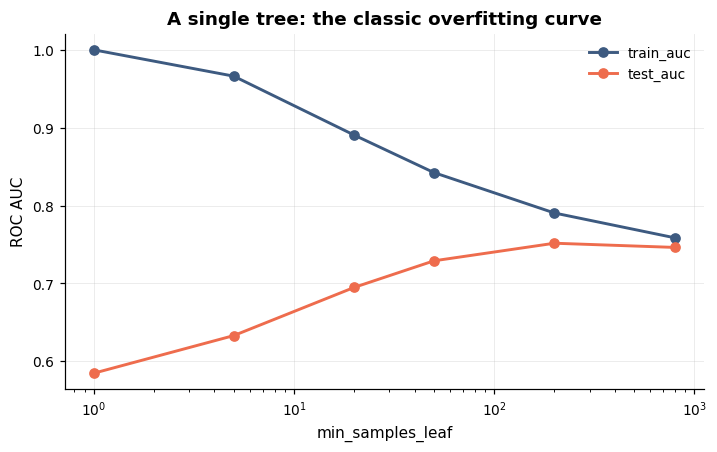

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate

X_num = X.select_dtypes(include=[np.number]).fillna(X.select_dtypes(include=[np.number]).median())
cv = StratifiedKFold(5, shuffle=True, random_state=0)

rows = []
for leaf in [1, 5, 20, 50, 200, 800]:
    r = cross_validate(DecisionTreeClassifier(min_samples_leaf=leaf, random_state=0),
                       X_num, y, cv=cv, scoring=["roc_auc"], return_train_score=True, n_jobs=-1)
    rows.append({"min_samples_leaf": leaf,
                 "train_auc": round(r["train_roc_auc"].mean(), 4),
                 "test_auc": round(r["test_roc_auc"].mean(), 4),
                 "gap": round(r["train_roc_auc"].mean() - r["test_roc_auc"].mean(), 4)})
overfit = pd.DataFrame(rows).set_index("min_samples_leaf")
ax = overfit[["train_auc", "test_auc"]].plot(marker="o", logx=True)
ax.set(ylabel="ROC AUC", title="A single tree: the classic overfitting curve")
overfit

best: ccp_alpha=3.42e-04, 18 leaves, AUC 0.7349
unpruned tree has 1,486 leaves


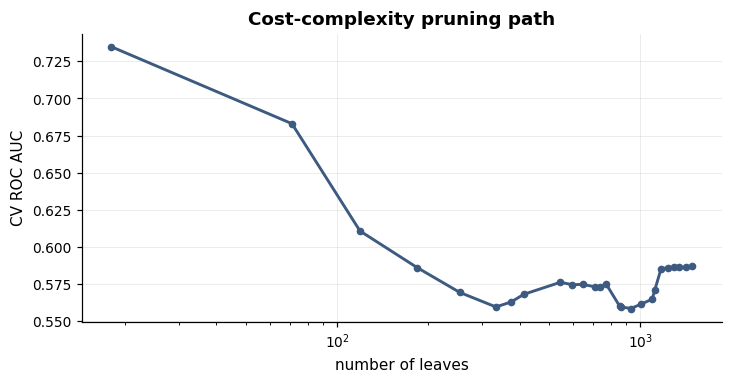

In [5]:
# Cost-complexity pruning: grow fully, then prune back along a principled path.
tree_full = DecisionTreeClassifier(random_state=0)
path = tree_full.cost_complexity_pruning_path(X_num, y)
alphas = path.ccp_alphas[:-1][::max(1, len(path.ccp_alphas) // 25)]

pruned = [DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(X_num, y) for a in alphas]
sizes = [t.get_n_leaves() for t in pruned]
scores = [cross_validate(DecisionTreeClassifier(random_state=0, ccp_alpha=a), X_num, y, cv=3, scoring="roc_auc", n_jobs=-1)["test_score"].mean() for a in alphas]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(sizes, scores, marker="o", ms=4)
ax.set(xscale="log", xlabel="number of leaves", ylabel="CV ROC AUC", title="Cost-complexity pruning path")
best_i = int(np.argmax(scores))
print(f"best: ccp_alpha={alphas[best_i]:.2e}, {sizes[best_i]} leaves, AUC {scores[best_i]:.4f}")
print(f"unpruned tree has {tree_full.fit(X_num, y).get_n_leaves():,} leaves")

## 3. Bagging and boosting are opposite arguments

This is the conceptual core of the module.

**Bagging (Random Forest).** A deep tree has *low bias and high variance* —
it fits the training data well but a different sample gives a very different
tree. Averaging many such trees, each fit on a bootstrap sample and a random
subset of features, cancels the variance while leaving the bias alone.
→ **Start with low-bias, high-variance models. Average away the variance.**

**Boosting.** A shallow tree has *high bias and low variance* — it
underfits, but stably. Fit one, then fit another to the *residual errors* of
the first, and add them. Each round reduces bias.
→ **Start with high-bias, low-variance models. Chip away at the bias.**

Everything else follows. Random forests are hard to overfit and easy to
parallelise (the trees are independent). Boosted models overfit readily,
require a learning rate and early stopping, and are inherently sequential.

In [6]:
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

# Variance reduction, demonstrated: how much does the prediction move when the
# training sample changes?
def prediction_variance(make_est, X, y, n_reps=12, n_probe=200):
    probe = X.iloc[:n_probe]
    preds = []
    for s in range(n_reps):
        idx = np.random.default_rng(s).choice(len(X), int(0.8 * len(X)), replace=False)
        est = make_est().fit(X.iloc[idx], y.iloc[idx])
        preds.append(est.predict_proba(probe)[:, 1])
    return np.array(preds).std(axis=0).mean()


for name, factory in [
    ("single deep tree", lambda: DecisionTreeClassifier(random_state=0)),
    ("bagging of 50 deep trees", lambda: BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=0, n_jobs=-1)),
    ("random forest (50)", lambda: RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=-1)),
    ("single depth-2 stump-ish tree", lambda: DecisionTreeClassifier(max_depth=2, random_state=0)),
]:
    print(f"{name:<32} mean prediction std across resamples: {prediction_variance(factory, X_num, y):.4f}")

single deep tree                 mean prediction std across resamples: 0.0944


bagging of 50 deep trees         mean prediction std across resamples: 0.0570


random forest (50)               mean prediction std across resamples: 0.0554
single depth-2 stump-ish tree    mean prediction std across resamples: 0.0313


The deep tree's predictions move a lot between resamples; bagging fifty of
them cuts that dramatically; the random forest cuts it further still, because
`max_features` decorrelates the trees on top of the bootstrap. The shallow
tree is stable *and* wrong — that is what "low variance, high bias" looks like.

In [7]:
# The whole family on one problem.
family = {
    "DecisionTree(leaf=20)": DecisionTreeClassifier(min_samples_leaf=20, random_state=0),
    "Bagging(50)": BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=0, n_jobs=-1),
    "RandomForest(300)": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1),
    "ExtraTrees(300)": ExtraTreesClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1),
    "AdaBoost(200)": AdaBoostClassifier(n_estimators=200, random_state=0),
    "GradientBoosting(200)": GradientBoostingClassifier(n_estimators=200, random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06, early_stopping=True),
}

rows = []
for name, est in family.items():
    r = cross_validate(est, X_num, y, cv=cv, scoring=["roc_auc", "average_precision"], return_train_score=True, n_jobs=-1)
    rows.append({"model": name,
                 "test_auc": round(r["test_roc_auc"].mean(), 4),
                 "±": round(r["test_roc_auc"].std(), 4),
                 "train_auc": round(r["train_roc_auc"].mean(), 4),
                 "test_ap": round(r["test_average_precision"].mean(), 4),
                 "fit_s": round(r["fit_time"].mean(), 2)})
pd.DataFrame(rows).sort_values("test_auc", ascending=False).set_index("model")

,test_auc,±,train_auc,test_ap,fit_s
model,,,,,
ExtraTrees(300),0.7704,0.0105,0.9513,0.4222,1.28
AdaBoost(200),0.7663,0.0096,0.7806,0.4034,1.22
GradientBoosting(200),0.7631,0.0097,0.8455,0.3991,2.44
HistGradientBoosting,0.7616,0.0069,0.8739,0.4086,0.12
RandomForest(300),0.7585,0.0111,0.9830,0.4098,3.27
Bagging(50),0.7323,0.0129,1.0000,0.3671,1.84
DecisionTree(leaf=20),0.6950,0.0127,0.8905,0.3271,0.05


### Reading that table like a practitioner

- The **train_auc** column separates the two philosophies at a glance. Bagged
  models sit near 1.0 in training (they memorise, then average); the boosted
  model with early stopping does not.
- The spread between the top few models is close to the noise floor from
  Module 04. **Do not declare a winner on a 0.003 difference.**
- `ExtraTrees` fits faster than `RandomForest` because it does not search for
  optimal thresholds — it picks random ones. On noisy data this extra
  randomisation often helps.

## 4. `HistGradientBoosting` — the parts people miss

sklearn's `HistGradientBoosting*` bins each feature into (by default) 255
buckets, which turns split-finding from a sort into a histogram scan. This is
the LightGBM idea, and it is why it is 10–100× faster than
`GradientBoostingClassifier` on anything sizeable. Three features beyond speed
are underused.

In [8]:
# (a) Native categorical support -- no encoding step at all.
hgb_native = HistGradientBoostingClassifier(
    categorical_features="from_dtype", random_state=0, max_iter=300, learning_rate=0.06, early_stopping=True
)
r_native = cross_validate(hgb_native, X_enc, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"native categoricals : {r_native['test_score'].mean():.4f} ± {r_native['test_score'].std():.4f}")

from sklearn.compose import make_column_selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

ohe_pipe = Pipeline([
    ("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                                 make_column_selector(dtype_include=["object", "string", "category"]))],
                               remainder="passthrough")),
    ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06, early_stopping=True)),
])
r_ohe = cross_validate(ohe_pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"one-hot encoded     : {r_ohe['test_score'].mean():.4f} ± {r_ohe['test_score'].std():.4f}")

native categoricals : 0.7624 ± 0.0085


one-hot encoded     : 0.7620 ± 0.0079


max_iter requested : 1000
n_iter_ used       : 86


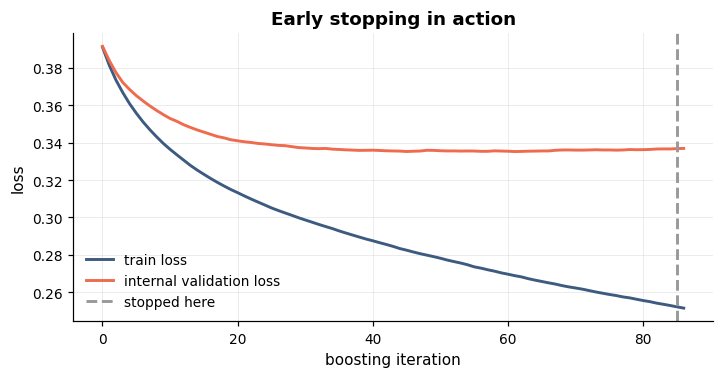

In [9]:
# (b) Early stopping is on by default above 10k samples. Inspect where it stopped.
hgb = HistGradientBoostingClassifier(
    random_state=0, max_iter=1000, learning_rate=0.05,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=25, scoring="loss",
).fit(X_enc, y)

print(f"max_iter requested : 1000")
print(f"n_iter_ used       : {hgb.n_iter_}")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(-hgb.train_score_, label="train loss")
ax.plot(-hgb.validation_score_, label="internal validation loss")
ax.axvline(hgb.n_iter_ - 1, ls="--", color="0.6", label="stopped here")
ax.set(xlabel="boosting iteration", ylabel="loss", title="Early stopping in action")
ax.legend()

**A caution about the internal validation split.** `early_stopping=True` holds
out `validation_fraction` of the *training data given to `fit`* — with a plain
random split. If your data is temporally ordered or grouped, that internal
split has the leakage properties you spent Module 04 avoiding. For grouped or
time-series problems, pass an explicit `X_val`/`y_val` where the API allows,
or turn early stopping off and tune `max_iter` with your own splitter.

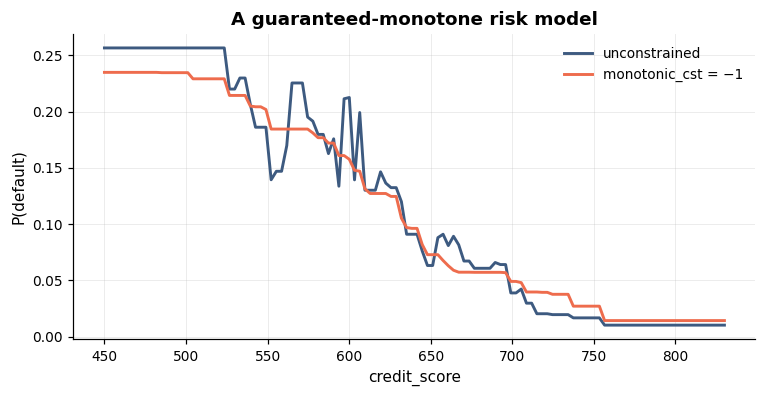

In [10]:
# (c) Monotonic constraints -- the feature that makes boosted trees deployable
# in regulated settings.
mono_cols = ["credit_score", "debt_to_income", "interest_rate"]
X_mono = X_enc[mono_cols].copy()

constraints = {"credit_score": -1, "debt_to_income": +1, "interest_rate": +1}

free = HistGradientBoostingClassifier(random_state=0, max_iter=250).fit(X_mono, y)
constrained = HistGradientBoostingClassifier(
    random_state=0, max_iter=250, monotonic_cst=[constraints[c] for c in mono_cols]
).fit(X_mono, y)

grid = pd.DataFrame({
    "credit_score": np.linspace(450, 830, 120),
    "debt_to_income": X_mono["debt_to_income"].median(),
    "interest_rate": X_mono["interest_rate"].median(),
})
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(grid["credit_score"], free.predict_proba(grid)[:, 1], label="unconstrained")
ax.plot(grid["credit_score"], constrained.predict_proba(grid)[:, 1], label="monotonic_cst = −1")
ax.set(xlabel="credit_score", ylabel="P(default)", title="A guaranteed-monotone risk model")
ax.legend()

> 💼 **Consulting lens.** `monotonic_cst` is the single most valuable
> scikit-learn feature for BFSI work and it is barely known. A model-risk
> committee will reject a credit model in which a *higher* bureau score can
> increase predicted default for some segment — even if it happens only in a
> sparse pocket of the feature space, and even if overall accuracy is better.
> Monotonic constraints make that impossible **by construction**, which turns
> a documentation argument into a structural guarantee. Cost is typically a
> fraction of a point of AUC. That is almost always a trade worth making, and
> being able to name it is worth a lot in a governance conversation.

In [11]:
# (d) Interaction constraints: restrict which features may appear in the same tree.
# Used to keep a model additive (and therefore explainable) in chosen blocks.
inter = HistGradientBoostingClassifier(
    random_state=0, max_iter=250, interaction_cst=[[0], [1], [2]]     # fully additive
).fit(X_mono, y)
print("fully additive model AUC (train):", round(inter.score(X_mono, y), 4))
print("unconstrained         AUC (train):", round(free.score(X_mono, y), 4))

fully additive model AUC (train): 0.8785
unconstrained         AUC (train): 0.8837


## 5. XGBoost, LightGBM, CatBoost

All three ship scikit-learn-compatible wrappers, so they drop into your
`Pipeline` and your `GridSearchCV` unchanged. That is the important structural
point: **they are estimators inside your harness, not alternatives to it.**

In [12]:
import warnings

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)

X_ord = X.copy()
for c in X_ord.select_dtypes(include=["object", "string"]).columns:
    X_ord[c] = X_ord[c].astype("category")

contenders = {
    "sklearn HistGB": HistGradientBoostingClassifier(random_state=0, max_iter=400, learning_rate=0.05, early_stopping=True),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, enable_categorical=True,
                             tree_method="hist", eval_metric="logloss", random_state=0, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, random_state=0, n_jobs=-1, verbose=-1),
}

rows = []
for name, est in contenders.items():
    r = cross_validate(est, X_ord, y, cv=cv, scoring=["roc_auc", "average_precision"], n_jobs=1)
    rows.append({"library": name,
                 "roc_auc": round(r["test_roc_auc"].mean(), 4),
                 "±": round(r["test_roc_auc"].std(), 4),
                 "avg_precision": round(r["test_average_precision"].mean(), 4),
                 "fit_s": round(r["fit_time"].mean(), 2)})
pd.DataFrame(rows).set_index("library")

,roc_auc,±,avg_precision,fit_s
library,,,,
sklearn HistGB,0.7632,0.0092,0.4068,0.17
XGBoost,0.7485,0.0096,0.3852,0.44
LightGBM,0.7481,0.0116,0.3879,0.44


### The honest comparison

| | sklearn `HistGB` | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|
| Accuracy on typical tabular data | within noise of the others | within noise | within noise | often best on categorical-heavy data |
| Speed | fast | fast | **fastest** on wide data | slower to train |
| Categorical handling | native | native (1.5+) | native | **best** (ordered target statistics) |
| GPU | no | yes | yes | yes |
| Missing values | native | native | native | native |
| Monotonic constraints | yes | yes | yes | yes |
| Extra dependency | **none** | yes | yes | yes |
| Hyperparameters to tune | ~6 | ~15 | ~15 | ~10 |
| Sensible out of the box | **yes** | needs tuning | needs tuning | yes |

**The decision rule I would actually give a team:** start with sklearn's
`HistGradientBoosting`. It has no extra dependency, sane defaults, and lands
within noise of the others on most tabular problems. Move to LightGBM when
training time genuinely constrains you or you have very wide data; to CatBoost
when categorical features dominate and their cardinality is high; to XGBoost
when the surrounding ecosystem (existing models, GPU serving, ONNX pipelines)
already assumes it.

Reaching for XGBoost by reflex on a 50k-row problem adds a dependency and a
tuning burden to buy a difference you cannot measure.

## 6. Stacking and voting

Ensembles of *different model families*. The argument is diversity: models
that make uncorrelated errors combine better than models that make the same
ones.

In [13]:
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

linear = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()), ("lr", LogisticRegression(max_iter=3000))])
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1)
boost = HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06, early_stopping=True)

base = [("linear", linear), ("forest", forest), ("boost", boost)]

ensembles = {
    "linear alone": linear,
    "forest alone": forest,
    "boost alone": boost,
    "Voting (soft)": VotingClassifier(base, voting="soft", n_jobs=-1),
    "Stacking (LR meta)": StackingClassifier(base, final_estimator=LogisticRegression(max_iter=2000), cv=5, n_jobs=-1),
}

rows = []
for name, est in ensembles.items():
    r = cross_validate(est, X_num, y, cv=cv, scoring="roc_auc", n_jobs=1)
    rows.append({"model": name, "roc_auc": round(r["test_score"].mean(), 4), "±": round(r["test_score"].std(), 4), "fit_s": round(r["fit_time"].mean(), 1)})
pd.DataFrame(rows).set_index("model")

,roc_auc,±,fit_s
model,,,
linear alone,0.7758,0.0092,0.0
forest alone,0.7585,0.0111,1.9
boost alone,0.7616,0.0069,0.1
Voting (soft),0.7697,0.0096,2.2
Stacking (LR meta),0.7738,0.0093,10.9


`StackingClassifier` internally uses `cross_val_predict` to build the
meta-features, so the meta-learner sees out-of-fold predictions and does not
leak. This is the correct implementation of a technique that is very easy to
get wrong by hand.

Note the `fit_s` column. Stacking costs roughly `(n_base × cv) + 1` fits. In a
competition that is free; in production it multiplies your training cost,
your artefact size, your inference latency and your explainability problem by
the number of base models. **Ask what the gain is in units the business
recognises before accepting that.**

## 7. Why `feature_importances_` misleads

Impurity-based importance ("mean decrease in impurity") counts how much each
feature reduced impurity across all splits. It has a **systematic bias towards
high-cardinality features**, because a feature with many distinct values
offers many candidate thresholds and will win some splits by chance.

The demonstration: add a pure-noise column with a unique value per row.

,impurity_importance
debt_to_income,0.1433
interest_rate,0.1313
credit_score,0.1216
random_noise,0.0892
annual_income,0.0884
random_id,0.0868
loan_amount,0.0861
employment_years,0.0749


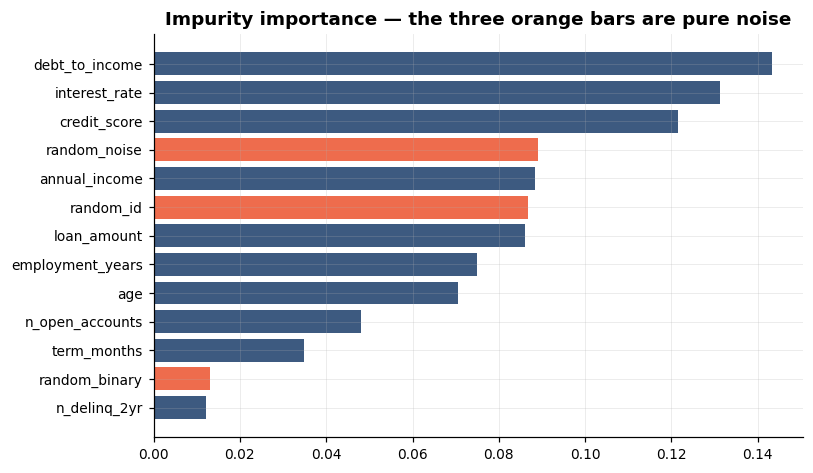

In [14]:
X_probe = X_num.copy()
X_probe["random_id"] = np.arange(len(X_probe))            # unique per row, zero signal
X_probe["random_noise"] = rng.normal(size=len(X_probe))   # continuous noise
X_probe["random_binary"] = rng.integers(0, 2, len(X_probe))

rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1).fit(X_probe, y)
imp = pd.Series(rf.feature_importances_, index=X_probe.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
colors = ["#ee6c4d" if n.startswith("random") else "#3d5a80" for n in imp.index]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1])
ax.set_title("Impurity importance — the three orange bars are pure noise")
plt.tight_layout()
imp.round(4).to_frame("impurity_importance").head(8)

A column of row indices ranks among the most "important" features in the
model. It contains no information. This is not a subtle effect and it is not
specific to this dataset.

Permutation importance — shuffle one column on **held-out** data and measure
how much the score drops — does not have this bias, because a useless column
costs nothing when shuffled. It is slower and it has its own failure mode with
correlated features. Module 12 covers both properly.

In [15]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(X_probe, y, test_size=0.3, stratify=y, random_state=0)
rf2 = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(Xtr, ytr)
perm = permutation_importance(rf2, Xte, yte, n_repeats=8, random_state=0, scoring="roc_auc", n_jobs=-1)

cmp = pd.DataFrame({
    "impurity": pd.Series(rf2.feature_importances_, index=X_probe.columns),
    "permutation": pd.Series(perm.importances_mean, index=X_probe.columns),
}).sort_values("permutation", ascending=False).round(4)
cmp

,impurity,permutation
credit_score,0.1241,0.0706
debt_to_income,0.1380,0.0354
interest_rate,0.1311,0.0129
annual_income,0.0893,0.0091
age,0.0706,0.0065
loan_amount,0.0865,0.0062
n_delinq_2yr,0.0124,0.0014
term_months,0.0347,0.0010
employment_years,0.0758,0.0006
random_binary,0.0138,-0.0007


`random_id`'s permutation importance collapses to ~0 while its impurity
importance stayed high. **Never present impurity importance to a stakeholder
as evidence of what drives a decision.**

## 8. Out-of-bag scoring

Each bootstrap sample leaves out ~37% of rows (`1/e`). A random forest can
score itself on those, giving a validation estimate for free.

In [16]:
from sklearn.metrics import roc_auc_score

oob = RandomForestClassifier(
    n_estimators=500, oob_score=True, min_samples_leaf=5, random_state=0, n_jobs=-1, bootstrap=True
).fit(X_num, y)

# `oob_score_` is accuracy by default, and `oob_score=<callable>` receives hard
# labels -- so for a probability metric, go to `oob_decision_function_`, which
# holds each row's averaged prediction from only the trees that did not see it.
oob_auc = roc_auc_score(y, oob.oob_decision_function_[:, 1])

cvres = cross_validate(RandomForestClassifier(n_estimators=500, min_samples_leaf=5, random_state=0, n_jobs=-1),
                       X_num, y, cv=cv, scoring="roc_auc", n_jobs=1)
print(f"OOB accuracy      : {oob.oob_score_:.4f}")
print(f"OOB ROC AUC       : {oob_auc:.4f}")
print(f"5-fold CV ROC AUC : {cvres['test_score'].mean():.4f}")
print("\nOOB costs one fit; CV costs five. On a large forest that matters.")

OOB accuracy      : 0.8768
OOB ROC AUC       : 0.7585
5-fold CV ROC AUC : 0.7600

OOB costs one fit; CV costs five. On a large forest that matters.


The caveat: OOB is a random-split estimate. It cannot respect groups or time,
so it inherits every problem Module 04 warned about. Use it as a cheap
sanity check during development, not as your reported number.

---
## Exercises

### Exercise 6.1 — Build a decision tree from scratch

Write a recursive `fit`/`predict` classification tree supporting `max_depth`
and `min_samples_leaf`, using Gini impurity. Then:

1. Match `DecisionTreeClassifier(max_depth=3)` node-for-node on
   `load_breast_cancer` — same features, same thresholds.
2. Add entropy as an option and find a dataset where the two criteria produce
   different trees.
3. Report your fit time versus sklearn's, and explain the gap.

In [17]:
# Your code here.

### Exercise 6.2 — Decompose bias and variance

Implement a bias–variance decomposition for squared error: over 100 bootstrap
training samples, compute for each test point the average prediction (→ bias²)
and the variance of predictions (→ variance).

Run it for tree depths 1–15 on a `make_regression` problem with noise, and
plot bias², variance and total error against depth. Then repeat for a
`RandomForestRegressor` and a `GradientBoostingRegressor` as a function of
`n_estimators`. Confirm the claim in section 3: bagging reduces variance and
leaves bias alone; boosting reduces bias and eventually increases variance.

In [18]:
# Your code here.

### Exercise 6.3 — The cost of monotonicity

On the credit data, fit `HistGradientBoostingClassifier` with and without
monotonic constraints on every feature where domain sense dictates a
direction (list them and justify each). Measure:

1. The AUC and average-precision cost of the constraint.
2. Whether the unconstrained model actually violates monotonicity — construct
   a test that varies one feature over a grid while holding others at
   realistic values, and count violations.
3. Whether the violations occur in dense or sparse regions of the data.

Write the paragraph you would put in a model documentation pack.

In [19]:
# Your code here.

### Exercise 6.4 — Library shoot-out done properly

Compare `HistGradientBoostingClassifier`, `XGBClassifier`, `LGBMClassifier`
and `CatBoostClassifier` on the credit data. Give each an equal tuning budget
(say 40 iterations of `RandomizedSearchCV` over a reasonable space) rather
than comparing defaults, and use `RepeatedStratifiedKFold` so you can compute
the noise floor.

Report: tuned score, time to tune, time to fit once, model size on disk, and
whether any difference exceeds the noise floor. Then write the two-sentence
recommendation. (If your honest answer is "it doesn't matter", say that —
it is the most useful finding this exercise can produce.)

In [20]:
# Your code here.

### Exercise 6.5 — Importance forensics

Build a dataset with: 3 genuinely informative features, 3 features that are
noisy copies of the informative ones, 1 high-cardinality noise column, and 3
low-cardinality noise columns.

Compute five importance measures — impurity, permutation on train,
permutation on test, drop-column, and SHAP — and put them in one table.
Which measures are fooled by which decoys? Write a short guide on which to
use when, aimed at someone who has to present the result to a non-technical
committee.

In [21]:
# Your code here.

---
## Takeaways

- A tree is a greedy search for impurity-reducing thresholds. That single
  sentence explains scale invariance, axis alignment and greediness.
- **Bagging and boosting are opposite arguments**: average away variance from
  low-bias learners, or chip away bias from low-variance learners.
- `min_samples_leaf` and `max_leaf_nodes` are the complexity knobs that earn
  their keep.
- `HistGradientBoosting` handles categoricals and NaN natively, stops early,
  and supports **monotonic and interaction constraints** — the last of which
  is the killer feature for regulated modelling.
- XGBoost/LightGBM/CatBoost are estimators inside your sklearn harness, not
  alternatives to it. Start with sklearn's; move only for a stated reason.
- `feature_importances_` is biased towards high-cardinality features. A column
  of row IDs will rank highly. Never present it as evidence.

**Next:** Module 07 — searching the hyperparameter space efficiently, and
knowing when to stop.